In [1]:
import torch
from torch import quantization
from ultralytics import YOLO
import torch.quantization as quant
import os
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
from onnxruntime.quantization import quantize_dynamic, QuantType
from onnxruntime.quantization import CalibrationDataReader, quantize_static, QuantType, QuantFormat
from pathlib import Path
import onnx
import onnxruntime  
import time
import netron
import onnxruntime
from tqdm.auto import tqdm

from help_fun import *

In [2]:
folder_path = Path('/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k/bdd100k/images/100k/val')

image_files = [f for f in os.listdir(folder_path) if f.endswith('.png') or f.endswith('.jpg')]

random_path = []

for _ in range(4):
    random_int = random.randint(0, len(image_files) - 1)
    random_path.append(os.path.join(folder_path, image_files[random_int]))

image_paths = [os.path.join(folder_path, i) for i in image_files]

random_path

['/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k/bdd100k/images/100k/val/c0568203-456be7fe.jpg',
 '/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k/bdd100k/images/100k/val/b26ba07a-da78f324.jpg',
 '/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k/bdd100k/images/100k/val/c37b9726-c2532aba.jpg',
 '/home/plorenc/Desktop/ADAS_for_poor/bdd100k_data/bdd100k/bdd100k/images/100k/val/c54a2f90-4762b269.jpg']


0: 384x640 7 cars, 1 traffic light, 3 traffic signs, 38.6ms
Speed: 2.7ms preprocess, 38.6ms inference, 568.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 5 traffic signs, 10.6ms
Speed: 1.9ms preprocess, 10.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 15 persons, 2 traffic lights, 3 traffic signs, 9.6ms
Speed: 1.5ms preprocess, 9.6ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 21 cars, 2 traffic signs, 2 trucks, 10.4ms
Speed: 1.1ms preprocess, 10.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


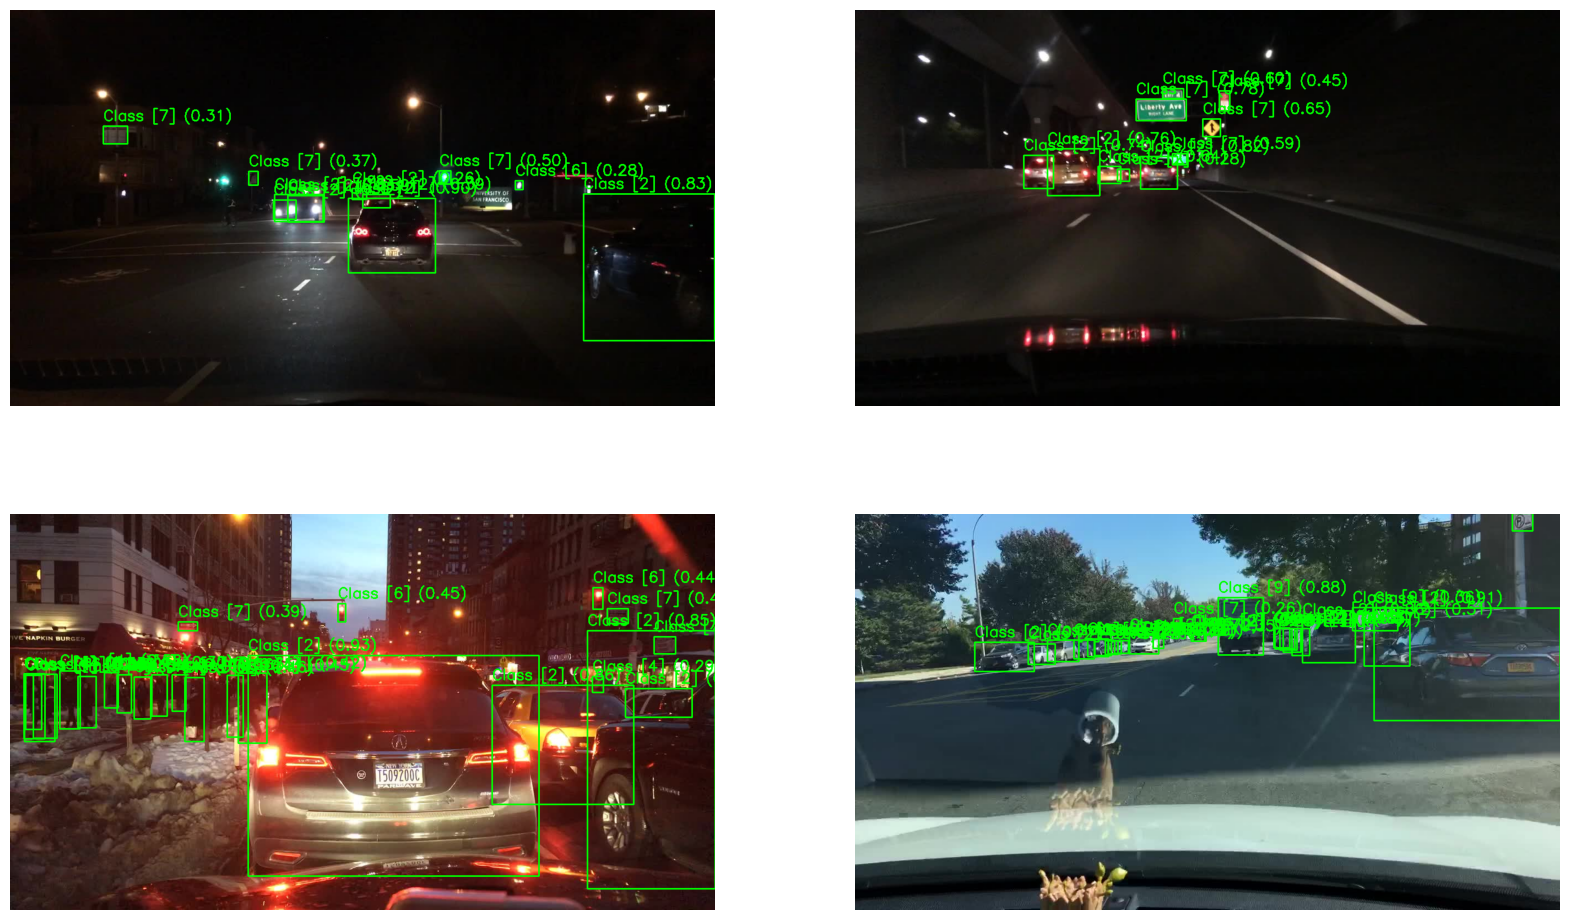

In [3]:
fig, axs = plt.subplots(2, 2, figsize = (20, 12))

axs = axs.flatten()

model = YOLO('chekpoints/best.pt')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

for idx, path in enumerate(random_path):
    img = imread_rgb(path)
    image = plot_prdictions(model, img)
    axs[idx].imshow(image)
    axs[idx].axis('off')

### Quant model

In [ ]:
model = YOLO('chekpoints/best.pt')
model.export(format='onnx')

Ultralytics 8.3.161 🚀 Python-3.12.3 torch-2.7.1+cu126 CPU (Intel Core(TM) i7-9750HF 2.60GHz)
YOLOv12n summary (fused): 159 layers, 2,558,678 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'chekpoints/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (5.2 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.58...
ONNX: export success ✅ 1.7s, saved as 'chekpoints/best.onnx' (10.1 MB)

Export complete (2.3s)
Results saved to /home/plorenc/Desktop/ADAS_for_poor/chekpoints
Predict:         yolo predict task=detect model=chekpoints/best.onnx imgsz=640  
Validate:        yolo val task=detect model=chekpoints/best.onnx imgsz=640 data=/home/plorenc/Desktop/ADAS_for_poor/yolo_config_100.yaml  
Visualize:       https://netron.app


'chekpoints/best.onnx'

In [ ]:
!python -m onnxruntime.quantization.preprocess --input '/home/plorenc/Desktop/ADAS_for_poor/chekpoints/best.onnx' --output '/home/plorenc/Desktop/ADAS_for_poor/chekpoints/preprocessed.onnx'

### Dynamic Quantization

In [ ]:
model_fp32 = Path('/home/plorenc/Desktop/ADAS_for_poor/onnx_model/preprocessed.onnx')
model_int8 = Path('/home/plorenc/Desktop/ADAS_for_poor/onnx_model/dynamic_quantized.onnx')

quantize_dynamic(model_fp32, model_int8, weight_type=QuantType.QUInt8)

### Static Quantization with onnx don't work. Below is test using torch

In [ ]:
model_path = 'onnx_model/preprocessed.onnx'
from IPython.display import IFrame

# Uruchamiamy Netron
netron.start(model_path)

IFrame('http://localhost:8080', width=800, height=600)


In [ ]:
import os
import cv2
import numpy as np
import onnx
from onnxruntime.quantization import CalibrationDataReader, quantize_static, QuantType, QuantFormat


class ImageCalibrationDataReader(CalibrationDataReader):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.idx = 0
        self.input_name = "images"

    def preprocess(self, frame):
        image_data = cv2.imread(frame)
        image_data = cv2.resize(image_data, (640, 640))
        image_data = np.array(image_data).astype(np.float32)  # Normalize to [0, 1] range
        image_data = np.transpose(image_data, (2, 0, 1))  # (H, W, C) -> (C, H, W)
        image_data = np.expand_dims(image_data, axis=0)  # Add batch dimension
        return image_data

    def get_next(self):
        if self.idx >= len(self.image_paths):
            return None

        image_path = self.image_paths[self.idx]
        input_data = self.preprocess(image_path)
        self.idx += 1
        return {self.input_name: input_data}


image_files = os.listdir(folder_path)
calibration_image_paths = [os.path.join(folder_path, p) for p in image_files][:2000]

calibration_data_reader = ImageCalibrationDataReader(calibration_image_paths)

quantize_static(
    'onnx_model/preprocessed.onnx',  
    'onnx_model/static_quantized.onnx', 
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QUInt8,
    calibration_data_reader=calibration_data_reader,
    quant_format=QuantFormat.QDQ,
    nodes_to_exclude=['/model.22/Concat_3', '/model.22/Split', '/model.22/Sigmoid'
                    '/model.22/dfl/Reshape', '/model.22/dfl/Transpose', '/model.22/dfl/Softmax', 
                    '/model.22/dfl/conv/Conv', '/model.22/dfl/Reshape_1', '/model.22/Slice_1',
                    '/model.22/Slice', '/model.22/Add_1', '/model.22/Sub', '/model.22/Div_1',
                    '/model.22/Concat_4', '/model.22/Mul_2', '/model.22/Concat_5'],
    per_channel=False,
    reduce_range=True,)
print("Quantization finished.")


Quantization finished.


10541674 3276588 3095233


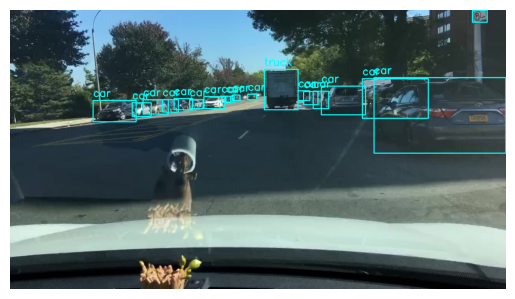

In [5]:
static_quantized = '/home/plorenc/Desktop/ADAS_for_poor/onnx_model/static_quantized.onnx'
dynamic_quantized = 'onnx_model/dynamic_quantized.onnx'
yolov8n = 'onnx_model/best.onnx'

yolo_size = os.path.getsize(yolov8n)
static_size = os.path.getsize(static_quantized)
dynamic_size = os.path.getsize(dynamic_quantized)

print(yolo_size, static_size, dynamic_size)

path = random_path[3]

inter = Inference("onnx_model/best.onnx")
boxes_and_classes = inter.pipeline(path)

inter.plot_bounding_box(path)

In [6]:
dynamic_quantized = 'onnx_model/dynamic_quantized.onnx'
static_quantized = 'onnx_model/static_quantized.onnx'
yolov8n = 'onnx_model/best.onnx'

session_fp32 = onnxruntime.InferenceSession(yolov8n, providers=["CPUExecutionProvider"])
session_int8_d = onnxruntime.InferenceSession(dynamic_quantized, providers=["CPUExecutionProvider"])
session_int8_s = onnxruntime.InferenceSession(static_quantized, providers=["CPUExecutionProvider"])

input_name = session_fp32.get_inputs()[0].name
input_shape = session_fp32.get_inputs()[0].shape  # [batch, 3, 640, 640]
input_height, input_width = input_shape[2], input_shape[3]

times_f32 = []
times_i8_d = []
times_i8_s = []

def preprocess(img, width, height):
    img = cv2.resize(img, (width, height))
    img = img.transpose(2, 0, 1)  # HWC → CHW
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)
    return img

# FP32
for path in tqdm(image_paths[:100], desc="FP32"):
    img = cv2.imread(path)
    input_data = preprocess(img, input_width, input_height)

    t0 = time.perf_counter()
    out_fp32 = session_fp32.run(None, {input_name: input_data})
    t1 = time.perf_counter()
    times_f32.append(t1 - t0)

# INT8 dynamic
for path in tqdm(image_paths[:100], desc="INT8 dynamic"):
    img = cv2.imread(path)
    input_data = preprocess(img, input_width, input_height)

    t0 = time.perf_counter()
    out_int8 = session_int8_d.run(None, {input_name: input_data})
    t1 = time.perf_counter()
    times_i8_d.append(t1 - t0)

# INT8 static
for path in tqdm(image_paths[:100], desc="INT8 static"):
    img = cv2.imread(path)
    input_data = preprocess(img, input_width, input_height)

    t0 = time.perf_counter()
    out_int8 = session_int8_s.run(None, {input_name: input_data})
    t1 = time.perf_counter()
    times_i8_s.append(t1 - t0)

# print results
print(f"Average FP32 time       : {np.mean(times_f32):.4f}s")
print(f"Average INT8 dynamic    : {np.mean(times_i8_d):.4f}s")
print(f"Average INT8 static     : {np.mean(times_i8_s):.4f}s")


FP32:   0%|          | 0/100 [00:00<?, ?it/s]

INT8 dynamic:   0%|          | 0/100 [00:00<?, ?it/s]

INT8 static:   0%|          | 0/100 [00:00<?, ?it/s]

Average FP32 time       : 0.0606s
Average INT8 dynamic    : 0.0833s
Average INT8 static     : 0.0493s


### Static Quantization using clear torch

In [ ]:
import torch
import torch.quantization
from torch.quantization import get_default_qconfig, prepare, convert
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

class MyCalibrationDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.transform = transforms.Compose([
            transforms.Resize((640,640)),
            transforms.ToTensor()
        ])
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img)

model_fp32 = YOLO("chekpoints/best.pt")

model_fp32 = model_fp32.model
model_fp32.eval()

qconfig = get_default_qconfig('fbgemm')
model_fp32.qconfig = qconfig

model_prepared = prepare(model_fp32)

image_files = os.listdir(folder_path)
calibration_image_paths = [os.path.join(folder_path, p) for p in image_files][:2000]
calib_dataset = MyCalibrationDataset(calibration_image_paths)
calib_loader = DataLoader(calib_dataset, batch_size=16)

with torch.no_grad():
    for batch in calib_loader:
        model_prepared(batch)

model_quantized = convert(model_prepared)

torch.save(model_quantized, "torch_model_quantized.pth")